 Imports & Configuration

In [19]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from IPython.display import display
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro, ks_2samp

# ── Configuration Minimaliste
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#FFFFFF',   # Fond d'image blanc pur
    'axes.facecolor':    '#FFFFFF',   # Fond de graphique blanc pur
    'axes.edgecolor':    '#E0E0E0',   # Bordures grises très douces
    'axes.labelcolor':   '#333333',   # Texte gris foncé (plus lisible que noir pur)
    'axes.titlecolor':   '#111111',   # Titre très foncé
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#555555',   
    'ytick.color':       '#555555',
    'text.color':        '#333333',   
    'grid.color':        '#F0F0F0',   # Grille très discrète
    'grid.linestyle':    '-',         # Ligne continue pour plus de propreté
    'grid.alpha':        0.8,
    'legend.facecolor':  '#FFFFFF',
    'legend.edgecolor':  '#E0E0E0',
    'legend.fontsize':   10,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,       # Supprime la bordure du haut (Minimalisme)
    'axes.spines.right': False,       # Supprime la bordure de droite (Minimalisme)
})

# ── Couleurs Métiers (Fraude vs Légitime) ───────────────────
# Approche classique et très lisible en présentation
FRAUD_COLOR  = '#D32F2F'   # Rouge vif (Alerte, Danger)
LEGIT_COLOR  = '#1976D2'   # Bleu corporatif (Confiance, Standard)
ACCENT_COLOR = '#FFA000'   # Ambre/Orange pour souligner des anomalies spécifiques
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

# Appliquer la palette à Seaborn
sns.set_palette(PALETTE)

In [20]:
df = pd.read_csv('../data/raw/credit_card_fraud_10k.csv')

 FEATURE ENGINEERING

In [21]:
# ── 1. Transformation logarithmique du montant ──────────────
# Réduit l'impact des montants extrêmes (outliers)
df['amount_log'] = np.log1p(df['amount'])

# ── 2. Indicateur de nuit (minuit à 6h du matin) ────────────
# Capture le pic d'activité frauduleuse nocturne
df['is_night'] = (df['transaction_hour'] < 6).astype(int)

# ── 3. Score Z (Standardisation) du montant ─────────────────
df['amount_zscore'] = (df['amount'] - df['amount'].mean()) / df['amount'].std()

# ── 4. Indicateur de montant élevé (> 75e centile) ──────────
q75 = df['amount'].quantile(0.75)
df['high_amount'] = (df['amount'] > q75).astype(int)

# ── 5. Catégorisation par quantiles du montant ──────────────
df['amount_bin'] = pd.qcut(df['amount'], q=5,
                           labels=['Très Faible', 'Faible', 'Moyen', 'Élevé', 'Très Élevé'],
                           duplicates='drop')

# ── 6. Indicateur de haute vélocité ─────────────────────────
# Les fraudeurs font souvent beaucoup de transactions très vite
df['high_velocity'] = (df['velocity_last_24h'] > df['velocity_last_24h'].median()).astype(int)

# ── 7. Score de risque composite ────────────────────────────
# Addition de signaux faibles/forts pour aider le modèle
df['risk_score'] = df['foreign_transaction'] + df['location_mismatch'] + df['high_velocity']

print(f"Création de {7} nouvelles caractéristiques terminée.")

Création de 7 nouvelles caractéristiques terminée.


In [22]:
new_features = ['amount_log', 'is_night', 'amount_zscore',
                'high_amount', 'amount_bin', 'high_velocity', 'risk_score']

print("\n" + "=" * 60)
print(" RÉSUMÉ DES NOUVELLES CARACTÉRISTIQUES")
print("=" * 60)
print(f"{'Caractéristique':<22} {'Type':<15} {'Non-nul':<10} Exemples")
print("-" * 65)

for feat in new_features:
    sample = df[feat].dropna().iloc[:3].tolist()
    sample_str = f"[{', '.join(str(round(x, 2)) if isinstance(x, float) else str(x) for x in sample)}]"
    print(f"{feat:<22} {str(df[feat].dtype):<15} {df[feat].notna().sum():<10} {sample_str}")

print(f"\n Nouvelle dimension du DataFrame : {df.shape}")


 RÉSUMÉ DES NOUVELLES CARACTÉRISTIQUES
Caractéristique        Type            Non-nul    Exemples
-----------------------------------------------------------------
amount_log             float64         10000      [4.45, 6.3, 5.47]
is_night               int64           10000      [0, 1, 0]
amount_zscore          float64         10000      [-0.52, 2.09, 0.35]
high_amount            int64           10000      [0, 1, 0]
amount_bin             category        10000      [Faible, Très Élevé, Élevé]
high_velocity          int64           10000      [1, 0, 0]
risk_score             int64           10000      [1, 1, 0]

 Nouvelle dimension du DataFrame : (10000, 17)


Correlation Heatmap : 
A correlation matrix tells us how linearly related each pair of features is, ranging from −1 (perfect inverse) to +1 (perfect positive).

In [23]:
# ── CARTE DE CHALEUR DES CORRÉLATIONS (HEATMAP) ─────────────
# Une matrice de corrélation nous indique dans quelle mesure chaque paire de variables 
# est linéairement liée, allant de -1 (inverse parfait) à +1 (positif parfait).

# Sélection des colonnes numériques pour la corrélation
numeric_cols = ['amount', 'amount_log', 'transaction_hour', 'is_night',
                'amount_zscore', 'high_amount', 'high_velocity',
                'risk_score', 'foreign_transaction', 'location_mismatch',
                'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']

# Calcul de la matrice de corrélation
corr_matrix = df[numeric_cols].corr()

print("Matrice de corrélation calculée avec succès sur les variables numériques.")

Matrice de corrélation calculée avec succès sur les variables numériques.


CARTE DE CHALEUR (HEATMAP) GLOBALE

Heatmap sauvegardée avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\correlation_heatmap_full.png



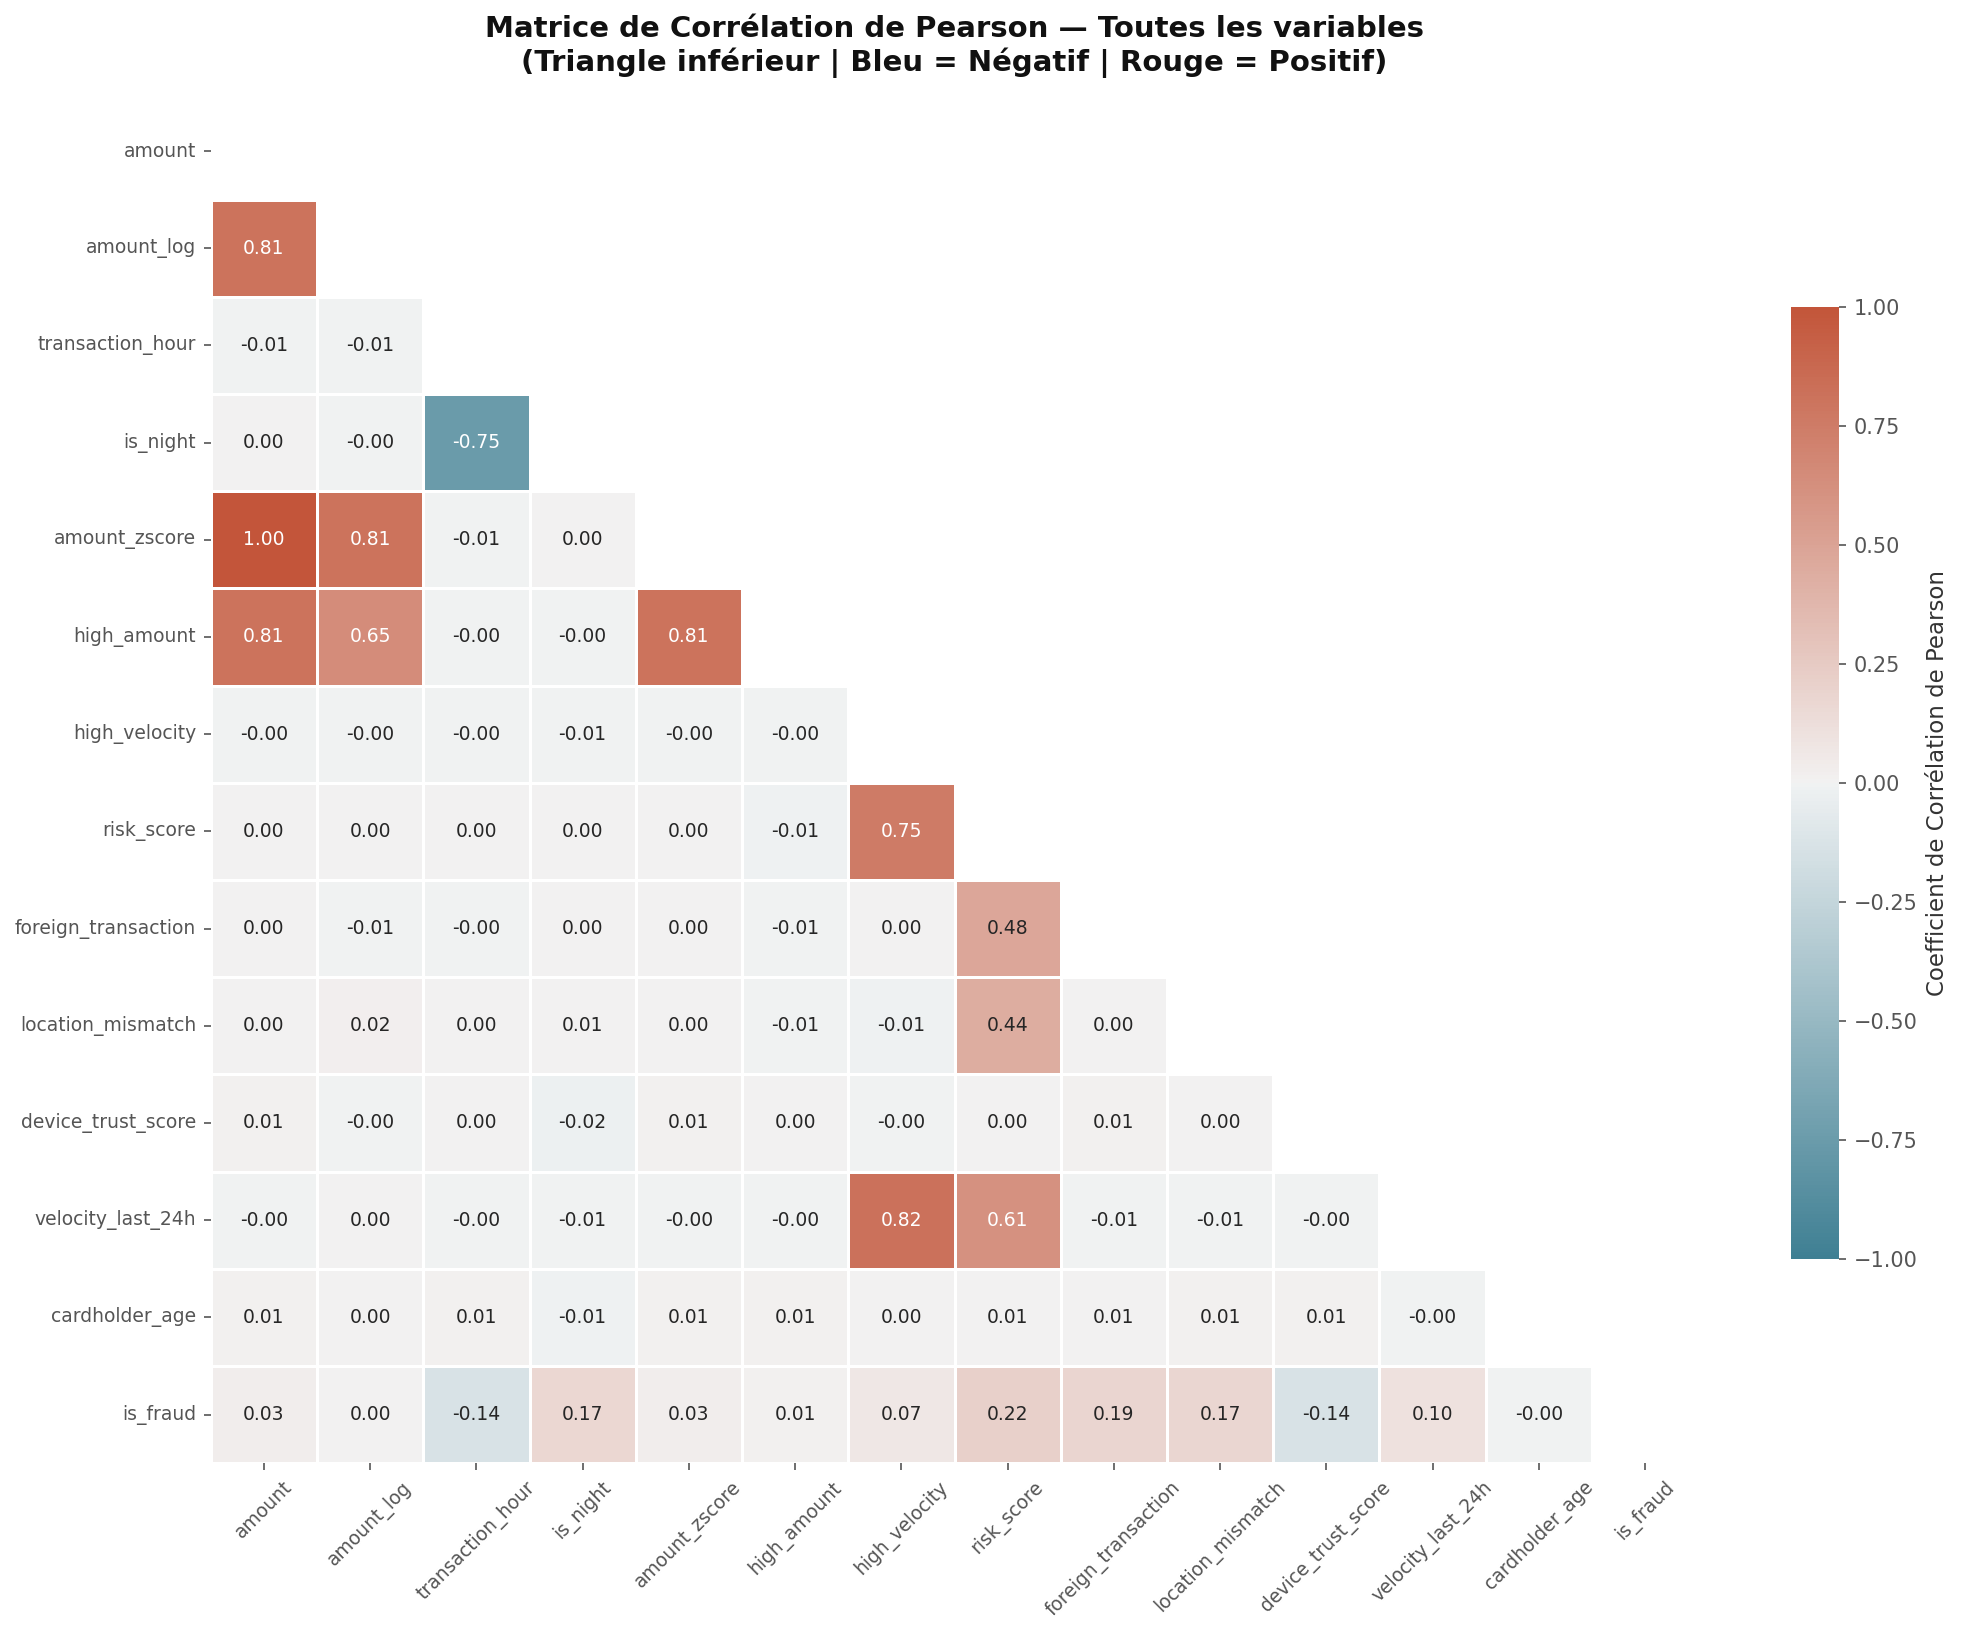

In [24]:
fig, ax = plt.subplots(figsize=(14, 11))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap, center=0,
    vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.5,
    linecolor='white', ax=ax, annot_kws={'size': 9},
    cbar_kws={'shrink': 0.7, 'label': 'Coefficient de Corrélation de Pearson'}
)

ax.set_title('Matrice de Corrélation de Pearson — Toutes les variables\n'
             '(Triangle inférieur | Bleu = Négatif | Rouge = Positif)',
             fontsize=14, fontweight='bold', pad=15)

ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()

# Sauvegarde
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_path1 = PLOT_DIR / 'correlation_heatmap_full.png'

plt.savefig(save_path1, bbox_inches='tight', dpi=300)
print(f"Heatmap sauvegardée avec succès dans : {save_path1}\n")

plt.show()

CORRÉLATIONS AVEC LA VARIABLE CIBLE (FRAUDE)

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\correlation_with_fraud.png



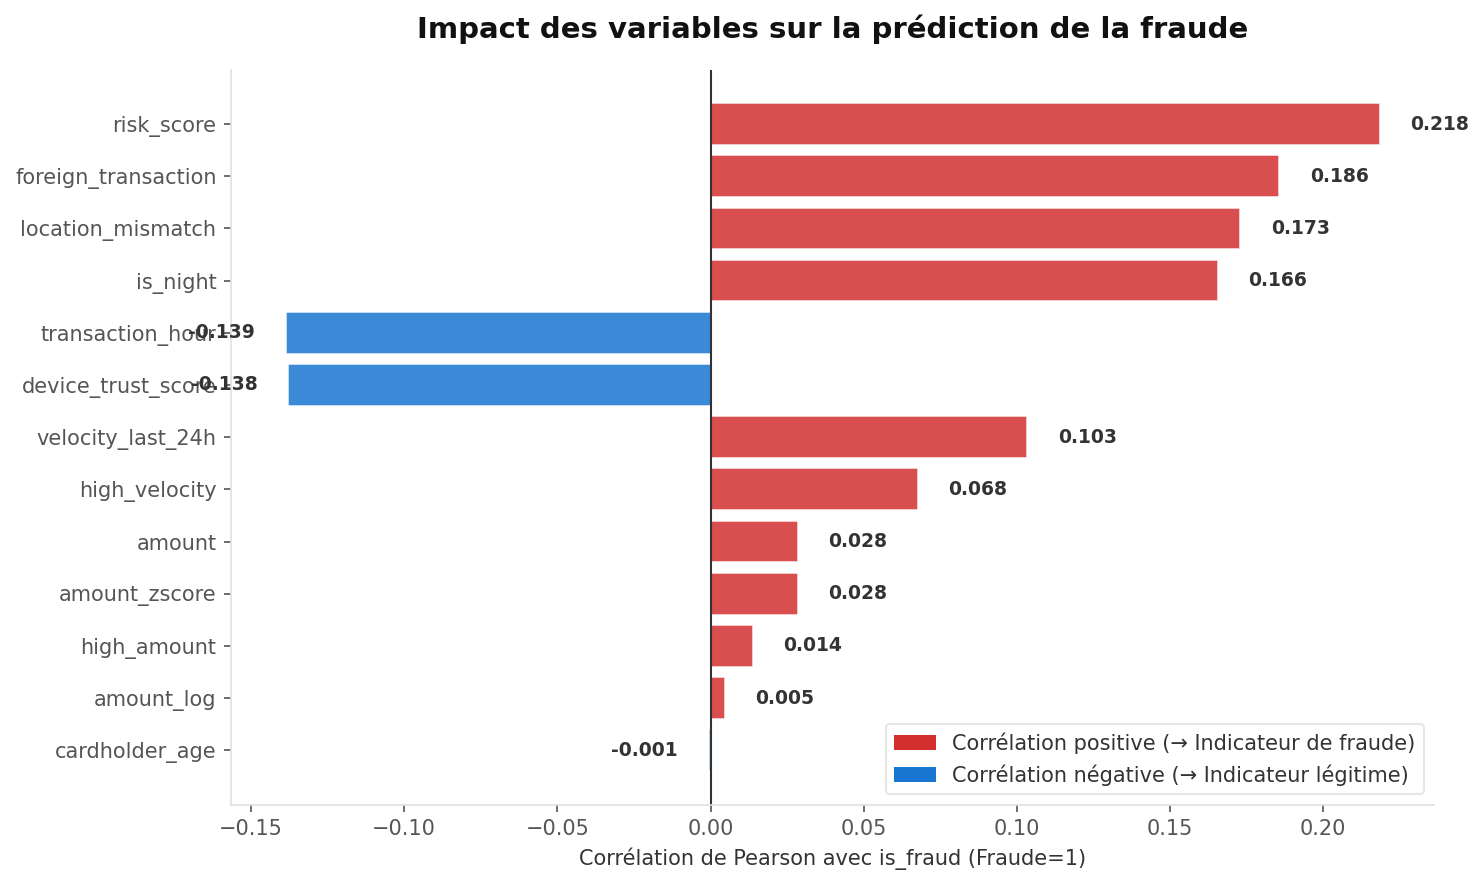

Classement des corrélations avec la fraude :
risk_score             0.218450
foreign_transaction    0.185597
location_mismatch      0.173009
is_night               0.165626
transaction_hour      -0.138665
device_trust_score    -0.137913
velocity_last_24h      0.103413
high_velocity          0.067639
amount                 0.028404
amount_zscore          0.028404
high_amount            0.013729
amount_log             0.004608
cardholder_age        -0.000590


In [25]:
class_corr = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
top_n = class_corr.head(13)

fig2, ax2 = plt.subplots(figsize=(10, 6))

colors = [FRAUD_COLOR if v > 0 else LEGIT_COLOR for v in top_n.values]
bars = ax2.barh(top_n.index[::-1], top_n.values[::-1],
                color=colors[::-1], alpha=0.85,
                edgecolor='white', linewidth=0.8)

# Ligne de base (0) en gris foncé pour la visibilité sur fond blanc
ax2.axvline(0, color='#333333', linewidth=1)

# Ajout des valeurs au bout des barres
for bar, val in zip(bars, top_n.values[::-1]):
    ax2.text(val + (0.01 if val > 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val > 0 else 'right',
             fontsize=9, fontweight='bold')

ax2.set_xlabel('Corrélation de Pearson avec is_fraud (Fraude=1)', fontsize=10)
ax2.set_title('Impact des variables sur la prédiction de la fraude',
              fontweight='bold', fontsize=14, pad=15)

# Légende traduite
legend_elements = [
    Patch(facecolor=FRAUD_COLOR, label='Corrélation positive (→ Indicateur de fraude)'),
    Patch(facecolor=LEGIT_COLOR,  label='Corrélation négative (→ Indicateur légitime)')
]
ax2.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()

# Sauvegarde
save_path2 = PLOT_DIR / 'correlation_with_fraud.png'
plt.savefig(save_path2, bbox_inches='tight', dpi=300)
print(f"Graphique sauvegardé avec succès dans : {save_path2}\n")

plt.show()

print("Classement des corrélations avec la fraude :")
print(class_corr.to_string())

ENCODAGE DES VARIABLES CATÉGORIELLES

In [26]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


df_model = df.copy()

# ── 1. Encodage de la catégorie du marchand ─────────────────
le_merchant = LabelEncoder()
df_model['merchant_category_enc'] = le_merchant.fit_transform(df_model['merchant_category'])

# ── 2. Encodage des tranches de montants ────────────────────
le_amount_bin = LabelEncoder()
df_model['amount_bin_enc'] = le_amount_bin.fit_transform(df_model['amount_bin'].astype(str))

print("Variables catégorielles transformées en valeurs numériques.")

# ── 3. Sauvegarde des encodeurs pour le pipeline PySpark ────────────────────
BASE_DIR = Path().resolve().parent
MODEL_DIR = BASE_DIR / 'ml-models' / 'trained'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarde de l'encodeur des marchands
merchant_encoder_path = MODEL_DIR / 'merchant_encoder.pkl'
joblib.dump(le_merchant, merchant_encoder_path)

# Sauvegarde de l'encodeur des tranches de montants
amount_bin_encoder_path = MODEL_DIR / 'amount_bin_encoder.pkl'
joblib.dump(le_amount_bin, amount_bin_encoder_path)

print(f"Encodeur Merchant exporté dans : {merchant_encoder_path}")
print(f"Encodeur Amount Bin exporté dans : {amount_bin_encoder_path}")

Variables catégorielles transformées en valeurs numériques.
Encodeur Merchant exporté dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\ml-models\trained\merchant_encoder.pkl
Encodeur Amount Bin exporté dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\ml-models\trained\amount_bin_encoder.pkl


SÉLECTION DES VARIABLES (FEATURES) POUR LE MODÈLE

In [27]:
# Liste définitive des 14 variables qui vont nourrir le modèle
feature_cols = [
    'amount', 'amount_log', 'transaction_hour', 'is_night',
    'foreign_transaction', 'location_mismatch', 'device_trust_score',
    'velocity_last_24h', 'cardholder_age', 'high_amount', 'high_velocity',
    'risk_score', 'merchant_category_enc', 'amount_bin_enc'
]

# X contient uniquement les données mathématiques d'entraînement
X = df_model[feature_cols]

# y contient la cible à prédire (0 = Légitime, 1 = Fraude)
y = df_model['is_fraud']

print(f"Variables indépendantes (X) : {X.shape[1]} colonnes prêtes.")
print(f"Variable cible (y) : '{y.name}' prête.")

Variables indépendantes (X) : 14 colonnes prêtes.
Variable cible (y) : 'is_fraud' prête.


SÉPARATION DES DONNÉES (TRAIN / TEST SPLIT)

In [ ]:
# Séparation : 80% pour l'entraînement (apprentissage) et 20% pour le test (évaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f" Jeu d'entraînement (Train) : {X_train.shape[0]:,} transactions")
print(f" Jeu de test (Test)       : {X_test.shape[0]:,} transactions")

print("\n Vérification de la stratification (Taux de fraude) :")
print(f"   Dans le Train : {y_train.mean()*100:.2f}% de fraudes")
print(f"   Dans le Test  : {y_test.mean()*100:.2f}% de fraudes")

 Jeu d'entraînement (Train) : 8,000 transactions
 Jeu de test (Test)       : 2,000 transactions

 Vérification de la stratification (Taux de fraude) :
   Dans le Train : 1.51% de fraudes
   Dans le Test  : 1.50% de fraudes


: 

Scale features

In [ ]:
scaler = StandardScaler()

# Apprend sur le Train et le transforme
X_train_scaled = scaler.fit_transform(X_train)

# Transforme le Test SANS apprendre dessus (très important pour éviter la fuite de données)
X_test_scaled  = scaler.transform(X_test)

print("Prétraitement terminé avec succès.")
print(f"   Taille du Train : {X_train.shape[0]:,} ({y_train.mean()*100:.2f}% de fraude)")
print(f"   Taille du Test  : {X_test.shape[0]:,} ({y_test.mean()*100:.2f}% de fraude)")
print(f"   Variables (X)   : {len(feature_cols)}")

# ── Sauvegarde du scaler pour le pipeline PySpark ────────────────────
BASE_DIR = Path().resolve().parent
MODEL_DIR = BASE_DIR / 'ml-models' / 'trained'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

scaler_path = MODEL_DIR / 'standard_scaler.pkl'
joblib.dump(scaler, scaler_path)

print(f"\nScaler exporté avec succès dans : {scaler_path}")

Prétraitement terminé avec succès.
   Taille du Train : 8,000 (1.51% de fraude)
   Taille du Test  : 2,000 (1.50% de fraude)
   Variables (X)   : 14

Scaler exporté avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\ml-models\trained\standard_scaler.pkl


SMOTE : GESTION DU DÉSÉQUILIBRE DES CLASSES

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Distribution des classes AVANT SMOTE :")
print(f"   Légitime : {Counter(y_train)[0]:,}")
print(f"   Fraude   : {Counter(y_train)[1]:,}")
print(f"   Ratio    : {Counter(y_train)[0]/Counter(y_train)[1]:.1f} pour 1")

# Paramètres standards : k_neighbors=5 est idéal pour ce type de données
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\n Distribution des classes APRÈS SMOTE :")
print(f"   Légitime : {Counter(y_train_sm)[0]:,}")
print(f"   Fraude   : {Counter(y_train_sm)[1]:,}")
print(f"   Ratio    : {Counter(y_train_sm)[0]/Counter(y_train_sm)[1]:.1f} pour 1")

print("\nLe jeu d'entraînement est désormais parfaitement équilibré (50/50) !")

Distribution des classes AVANT SMOTE :
   Légitime : 7,879
   Fraude   : 121
   Ratio    : 65.1 pour 1

 Distribution des classes APRÈS SMOTE :
   Légitime : 7,879
   Fraude   : 7,879
   Ratio    : 1.0 pour 1

Le jeu d'entraînement est désormais parfaitement équilibré (50/50) !


Visualize SMOTE effect

Graphique sauvegardé avec succès dans : C:\Users\Lenovo T470\OneDrive\Documents\GitHub\fraud-detection-realtime\notebooks\plots\smote_effect.png



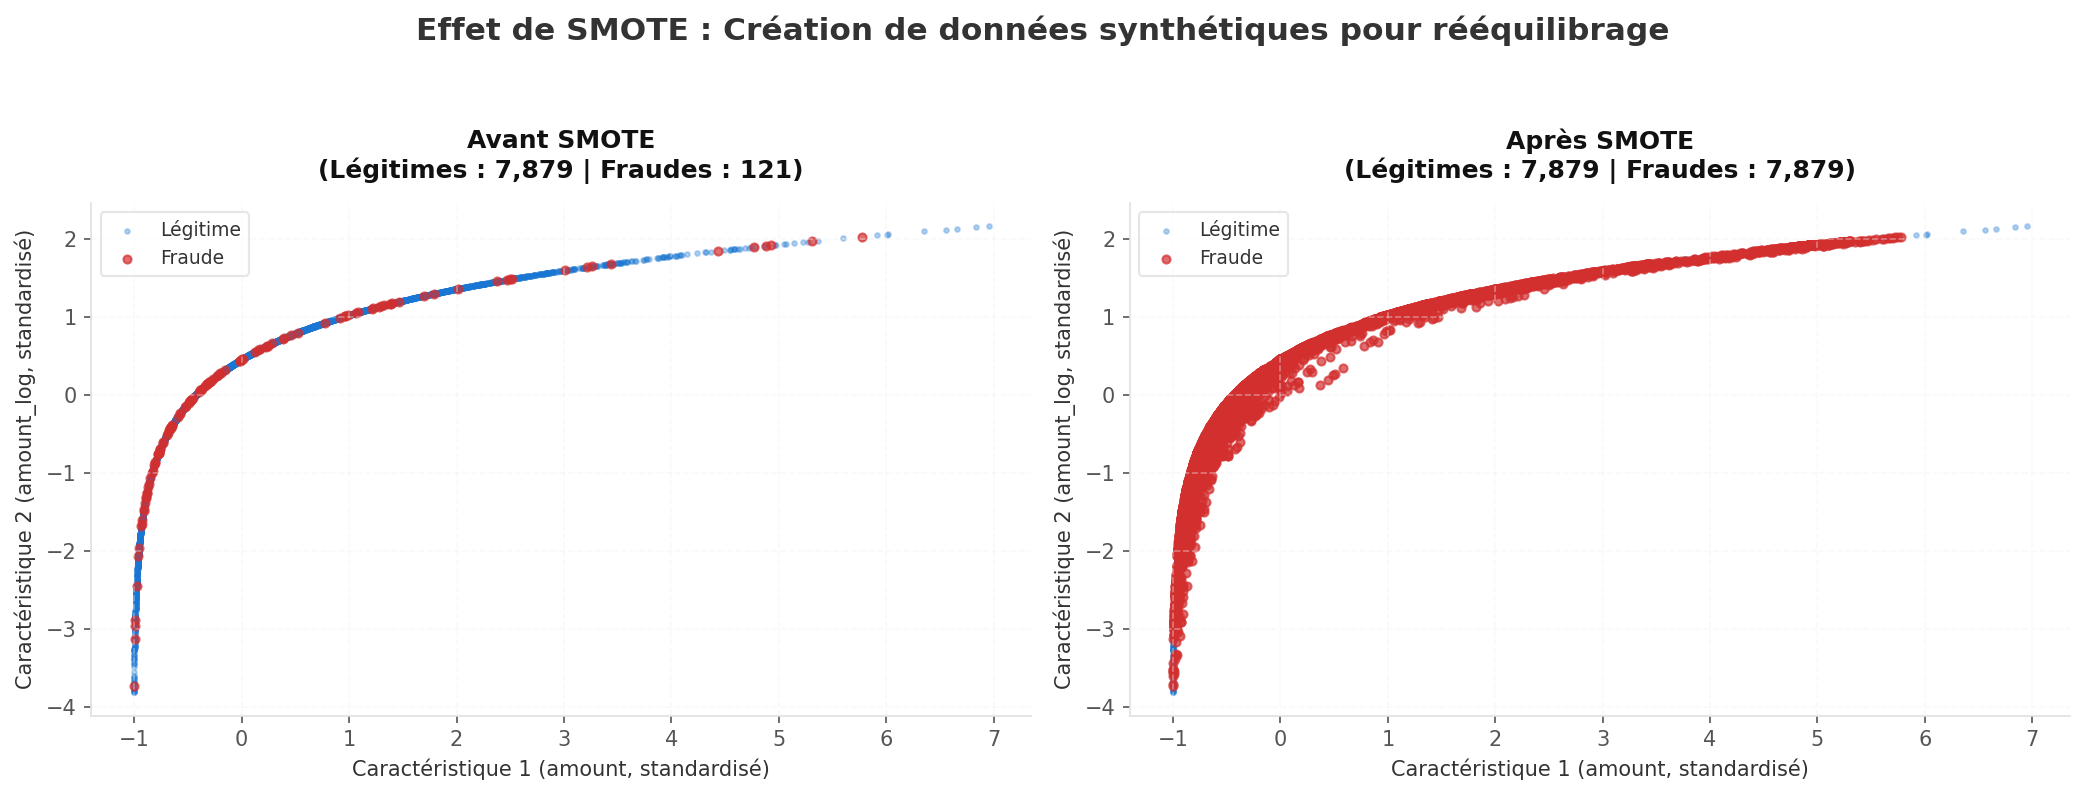

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boucle pour générer les deux graphiques côte à côte
for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train_scaled, y_train,    'Avant SMOTE'),
    (X_train_sm,     y_train_sm, 'Après SMOTE')
]):
    
    # Affichage des transactions légitimes (en fond, plus transparentes)
    ax.scatter(X_plot[y_plot == 0, 0], X_plot[y_plot == 0, 1],
               color=LEGIT_COLOR, alpha=0.3, s=5, label='Légitime')
    
    # Affichage des fraudes (au premier plan, plus grosses)
    ax.scatter(X_plot[y_plot == 1, 0], X_plot[y_plot == 1, 1],
               color=FRAUD_COLOR, alpha=0.7, s=15, label='Fraude')
    
    # Titre dynamique avec le comptage exact des classes
    ax.set_title(f'{title}\n(Légitimes : {Counter(y_plot)[0]:,} | Fraudes : {Counter(y_plot)[1]:,})',
                 fontweight='bold', fontsize=12, pad=12)
    
    # Libellés des axes
    ax.set_xlabel('Caractéristique 1 (amount, standardisé)', fontsize=10)
    ax.set_ylabel('Caractéristique 2 (amount_log, standardisé)', fontsize=10)
    
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.4, linestyle='--')

plt.suptitle('Effet de SMOTE : Création de données synthétiques pour rééquilibrage',
             fontsize=15, fontweight='bold', y=1.05)

plt.tight_layout()

# ── Sauvegarde ──────────────────────────────────────────────
BASE_DIR = Path().resolve().parent
PLOT_DIR = BASE_DIR / 'notebooks' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
save_path = PLOT_DIR / 'smote_effect.png'

plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Graphique sauvegardé avec succès dans : {save_path}\n")

plt.show()

SAUVEGARDE DES DONNÉES PRÉTRAITÉES

In [ ]:
# ── 1. Création du dossier de destination ───────────────────
BASE_DIR = Path().resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── 2. Sauvegarde au format CSV ─────────────────────────────
# Les données NumPy sont reconverties en DataFrames Pandas pour garder les noms de colonnes
pd.DataFrame(X_train_sm,    columns=feature_cols).to_csv(PROCESSED_DIR / 'X_train.csv', index=False)
pd.DataFrame(X_test_scaled, columns=feature_cols).to_csv(PROCESSED_DIR / 'X_test.csv',  index=False)

pd.Series(y_train_sm, name='is_fraud').to_csv(PROCESSED_DIR / 'y_train.csv', index=False)
pd.Series(y_test,     name='is_fraud').to_csv(PROCESSED_DIR / 'y_test.csv',  index=False)

print(f"\n Fichiers sauvegardés avec succès dans : {PROCESSED_DIR.relative_to(BASE_DIR)}")
print(f"   X_train.csv → {X_train_sm.shape} (Entraînement équilibré)")
print(f"   X_test.csv  → {X_test_scaled.shape} (Test non touché par SMOTE)")
print(f"   y_train.csv → {len(y_train_sm):,} lignes")
print(f"   y_test.csv  → {len(y_test):,} lignes")


 Fichiers sauvegardés avec succès dans : data\processed
   X_train.csv → (15758, 14) (Entraînement équilibré)
   X_test.csv  → (2000, 14) (Test non touché par SMOTE)
   y_train.csv → 15,758 lignes
   y_test.csv  → 2,000 lignes


In [ ]:
# 1. VELOCITY_MEDIAN
vel_median = df['velocity_last_24h'].median()
print(f"VELOCITY_MEDIAN = {vel_median}")

# 2. AMOUNT_Q75
q75 = df['amount'].quantile(0.75)
print(f"AMOUNT_Q75 = {q75}")

# 3. AMOUNT_BINS (Limites exactes des 5 tranches)
_, bins = pd.qcut(df['amount'], q=5, retbins=True)
# Remplacer la première et dernière valeur par l'infini pour capturer tous les cas futurs
bins[0] = -np.inf
bins[-1] = np.inf
# Formatage propre pour faire un copier-coller
bins_str = "[" + ", ".join([str(round(b, 2)) if b != np.inf and b != -np.inf else str(b) for b in bins]) + "]"
print(f"AMOUNT_BINS = {bins_str}")

VELOCITY_MEDIAN = 2.0
AMOUNT_Q75 = 242.48
AMOUNT_BINS = [-inf, 39.35, 90.48, 160.39, 285.8, inf]
